In [46]:
import numpy as np
import matplotlib.pyplot as plt
eps = np.finfo(float).eps

## Notes:
<b> Vanilla Gradient Descent</b> uses a fixed step size
\
<b> Gradient Descent with Exact Line Search</b> determines optimal step size to minimized objective function


# Task:
Implement vanilla gradient descent, gradient descent with exact line search, and Nesterov’s
accelerated gradient for a strongly convex quadratic. Plot convergence (log error vs. itera-
tion) for all three on the same semilogy plot.

## Definitions

A strongly convex quadratic function is $$f(X) = \frac{1}{2} x^T Ax - b^T x$$
The gradient is $$\nabla f(x) = Ax - b$$
And the optimal step size $\alpha$ that is the value which minimizes $f(x-a\nabla f(x))$
$$\text{argmin} f(x - \alpha \nabla f(x))$$
$$\alpha_k = \frac{|| - \nabla f(x_k) ||^2} {(-\nabla f(x_k)^T A (-\nabla f(x_k)))}$$

Nesterov's Gradient
$w$ is weight, $\beta$ is momentum and $v_{t-1}$ is previous velocity term, $\eta$ is learning rate.
\
Calculate Look Ahead Point
$$w_{\text{look ahead}} = w - \beta * v_{t-1}$$
Calculate Gradient at Look Ahead
$$\text{Gradient} = \nabla f(w_{\text{look-ahead}})$$
Update Velocity Term
$$v_t = \beta*v_{t-1} + \eta *\text{gradient}$$
Update Weights
$$w = w - v_t$$
Nesterov reduces oscillations around minimum, and often reaches convergence faster

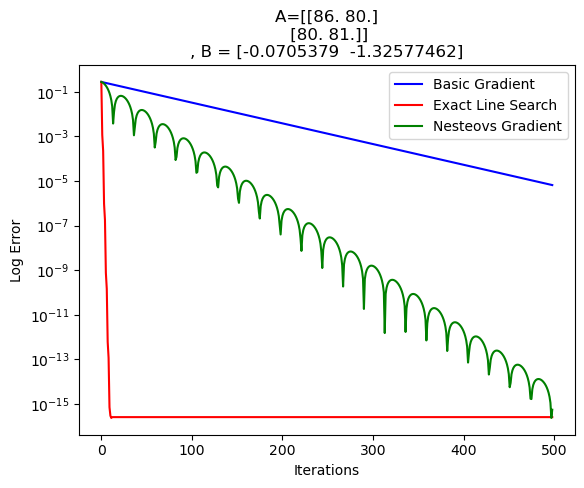

In [47]:
def f(A, b, x):
    # x = np.array([xV, yV])
    # quadTerm = 0.5 * (xV**2 * A[0,0] + xV*yV *(A[0,1]+A[1,0])+yV **2 *A[1,1])
    # other = b[0]*xV + b[1]*yV
    # return quadTerm - other
    return 0.5 * x.T @A@x - b.T@x
def Basic_Gradient(A, b, start, learningRate, iterations, exact):
    x = start.copy()
    errors = []
    for i in iterations:
        gradient = A @ x - b
        x = x - learningRate * gradient
        # approxValue = np.array([f(x[0],x[1])])
        # error_vector = np.abs(exact - approxValue)
        errors.append(np.linalg.norm(x - exact)) #l2 norm
    return x, errors
def gradient_with_ExactLine(A, b, start, iterations, exact):
    x = start.copy()
    errors = []
    for i in iterations:
        gradient = A @ x -b
        #check for convergence using norm of the gradient 
        if np.linalg.norm(gradient) < tol:
            # print(f"Converged")
            errors.extend([errors[-1]] * (len(iterations)-len(errors)))
            break
            #return x
        numerator = (gradient @ gradient) 
        denominator = (gradient.T) @ A @ gradient 
        alpha = numerator/denominator
        x = x- alpha * gradient
        # approxValue = np.array([f(x[0],x[1])])
        # error_vector = np.abs(exact - approxValue)
        errors.append(np.linalg.norm(x - exact)) 
    return x, errors
def nesterovs_gradient(A, b, start, learningRate, iterations, exact, momentum = 0.9):
    x = start.copy()
    y = start.copy() #look ahead point
    velocity = np.zeros_like(start)
    errors = []
    for i in iterations:
        #step in direction of previous velocity
        lookAhead = x+momentum * velocity
        #gradient at look ahead
        gradient = A@ lookAhead - b 
        #update velocity 
        velocity = momentum * velocity - learningRate * gradient 
        #update position
        x =  x + velocity
        # approxValue = np.array([f(x[0],x[1])])
        # error_vector = np.abs(exact - approxValue)
        errors.append(np.linalg.norm(x - exact)) 
    return x, errors

""" define the values for the function """
# np.random.seed(13)
A = np.random.randint(1, 10, size=(2,2)) #low, high
A = A.T @ A + np.eye(2) #make sure eigenvalues are positive 
b = np.random.randn(2)
x_initial = np.ones(2)
tol = eps

L = np.max(np.linalg.eigvals(A))
learningRate = 1/L #Lipschitz constant 
iterations = np.arange(1,500,1)
exact = np.array([np.linalg.solve(A,b)])
xBG, errorsBG = Basic_Gradient(A, b, x_initial, learningRate, iterations, exact)
xGE, errorsGE = gradient_with_ExactLine(A, b, x_initial, iterations, exact)
xNG, errorsNG = nesterovs_gradient(A, b, x_initial, learningRate, iterations, exact)
plt.title(f"A={A}\n, B = {b}")
plt.semilogy(np.arange(len(errorsBG)), errorsBG, 'b-', np.arange(len(errorsGE)), errorsGE, 'r-', np.arange(len(errorsNG)), errorsNG, 'g-')
plt.xlabel('Iterations')
plt.ylabel('Log Error')
plt.legend(['Basic Gradient', 'Exact Line Search', 'Nesteovs Gradient'])
plt.show();

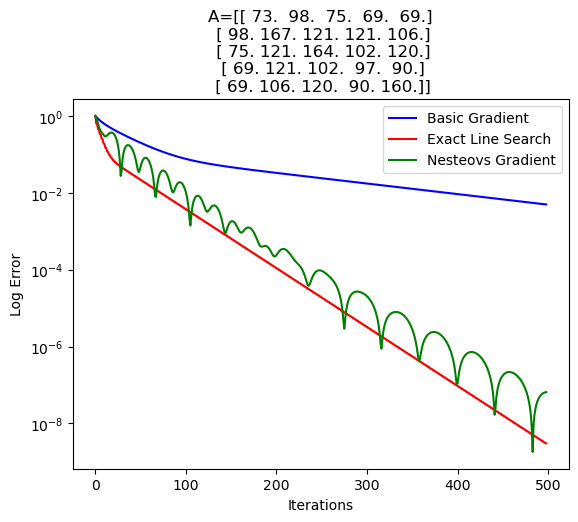

In [3]:
size = 5
A = np.random.randint(1, 10, size=(size,size)) #low, high
A = A.T @ A + np.eye(size) #make sure eigenvalues are positive 
b = np.random.randn(size)
x_initial = np.random.randn(size)
# Set momentum high 
L = np.max(np.linalg.eigvals(A))
learningRate = 1/L #Lipschitz constant 
iterations = np.arange(1,500,1)
exact = np.array([np.linalg.solve(A,b)])
xBG, errorsBG = Basic_Gradient(A, b, x_initial, learningRate, iterations, exact)
xGE, errorsGE = gradient_with_ExactLine(A, b, x_initial, iterations, exact)
xNG, errorsNG = nesterovs_gradient(A, b, x_initial, learningRate, iterations, exact, momentum =0.95)
plt.title(f"A={A}")
plt.semilogy(np.arange(len(errorsBG)), errorsBG, 'b-', np.arange(len(errorsGE)), errorsGE, 'r-', np.arange(len(errorsNG)), errorsNG, 'g-')
plt.xlabel('Iterations')
plt.ylabel('Log Error')
plt.legend(['Basic Gradient', 'Exact Line Search', 'Nesteovs Gradient'])
plt.show();

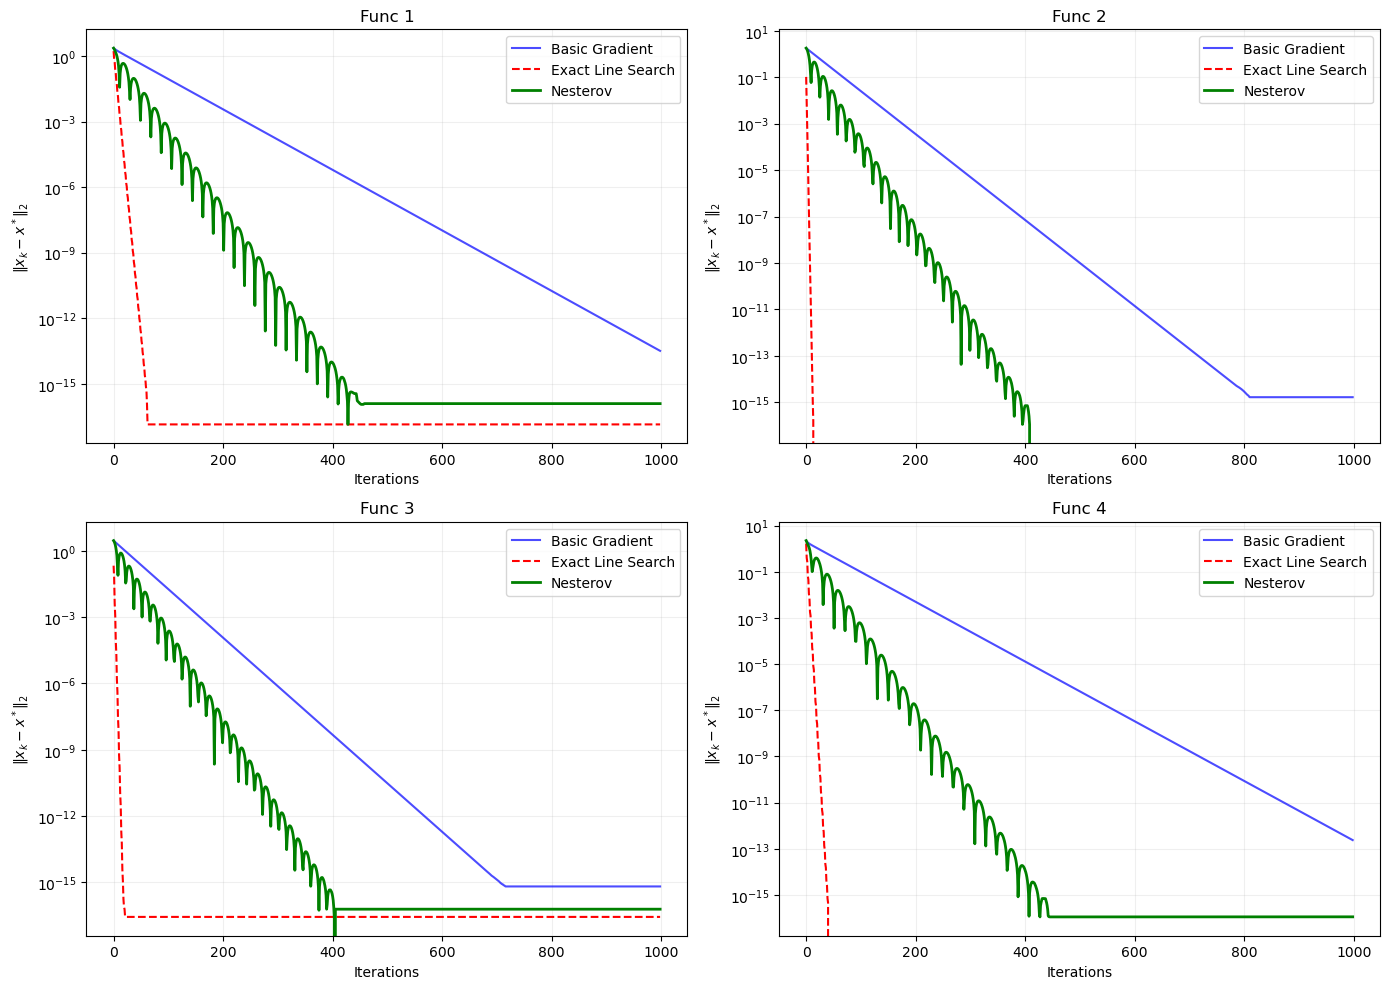

In [48]:
plt.figure(figsize=(14,10))
iterations = np.arange(1,1000)
for j in range(4):
    tmp = np.random.randn(2,2)
    A = tmp.T @ tmp +np.eye(2)
    b = np.random.randn(2)
    x_initial = np.array([2.0, -2.0])
    exact = np.linalg.solve(A,b)
    eigvals = np.linalg.eigvals(A)
    L = np.max(eigvals)
    mu = np.min(eigvals)
    lr = 1/L

    momentum = 0.875
    _, errorVan = Basic_Gradient(A, b, x_initial, learningRate, iterations, exact)
    _, errorExactLine = gradient_with_ExactLine(A, b, x_initial, iterations, exact)
    _, errorNesterov = nesterovs_gradient(A, b, x_initial, learningRate, iterations, exact, momentum)

    plt.subplot(2,2,j+1)
    iters_range = range(len(iterations))
    plt.semilogy(iters_range, errorVan, label='Basic Gradient', color='blue', alpha=0.7)
    plt.semilogy(iters_range, errorExactLine, label='Exact Line Search', color='red', linestyle='--')
    plt.semilogy(iters_range, errorNesterov, label='Nesterov', color='green', linewidth=2)
    plt.title(f"Func {j+1}")
    plt.xlabel("Iterations")
    plt.ylabel('$\|x_k - x^*\|_2$')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

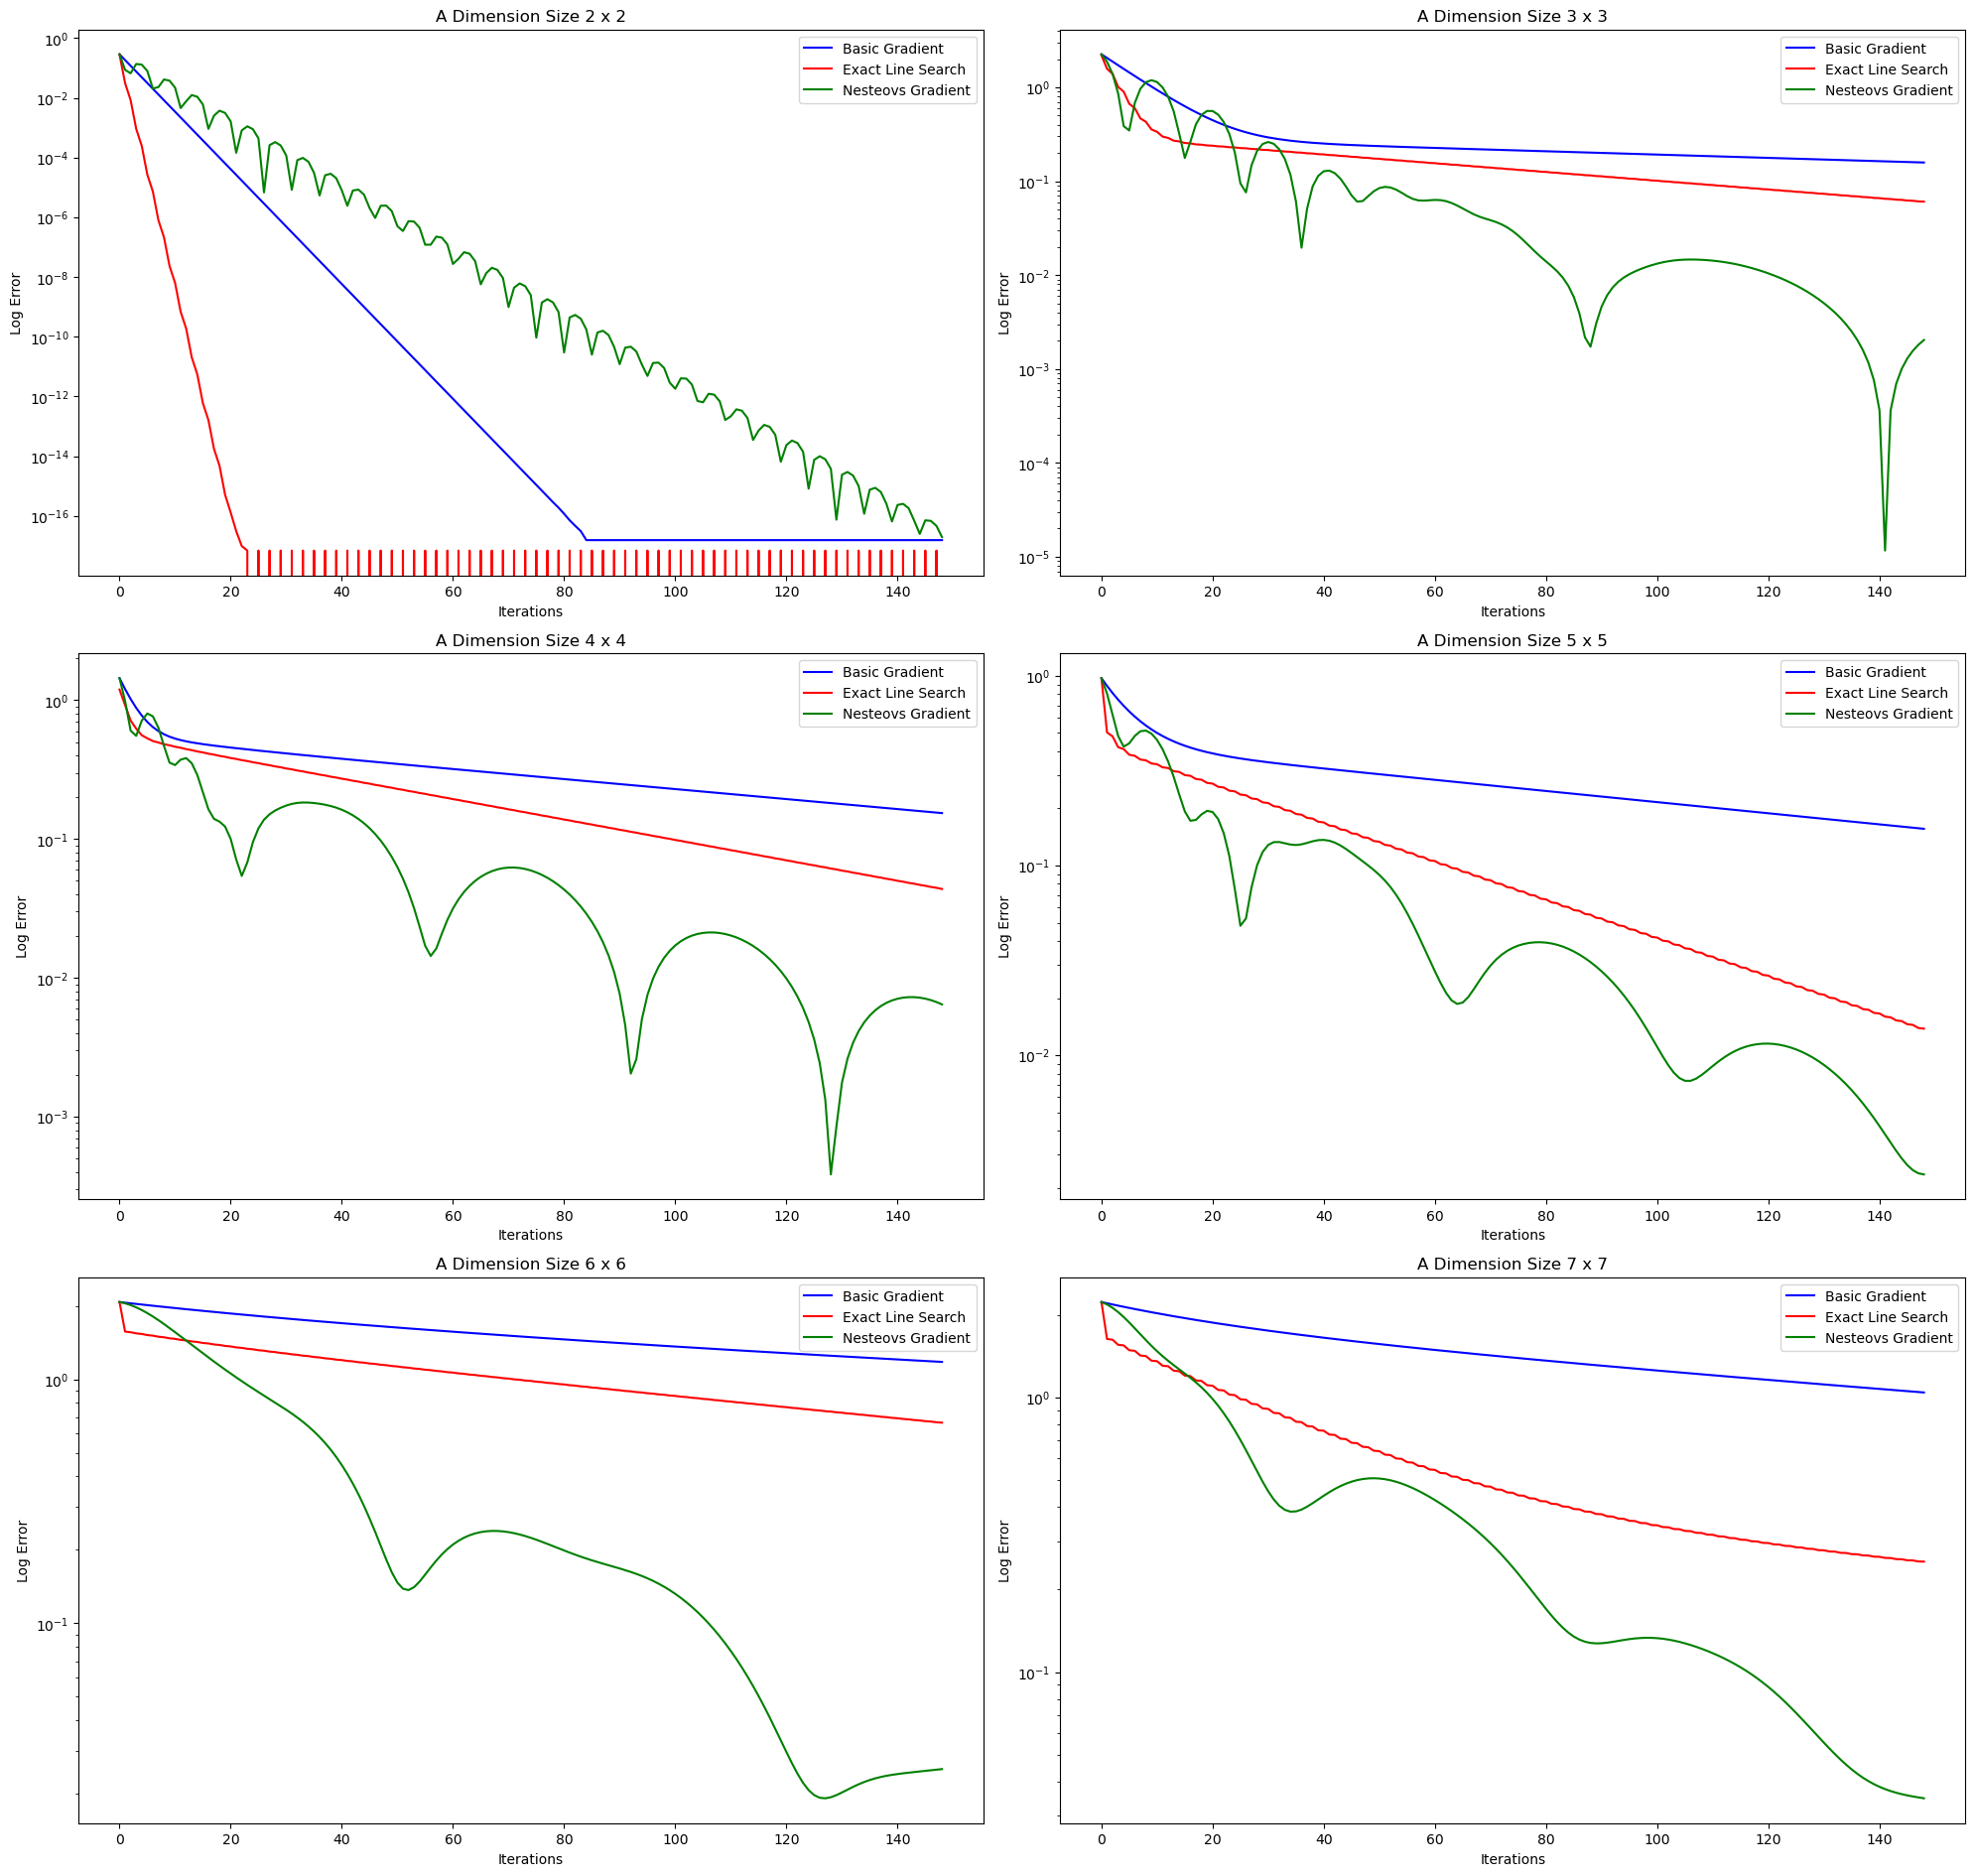

In [4]:
plt.figure(figsize=(20,50))
i = 0
maxDimensions = 8
for j in range(2,maxDimensions):
    tmp = np.random.randint(1,10, size=(j,j))
    A = tmp.T @ tmp +np.eye(j)
    b = np.random.randn(j)
    x_initial = np.random.randn(j)
    exact = np.linalg.solve(A,b)
    L = np.max(np.linalg.eigvals(A))
    learningRate = 1/L #Lipschitz constant 
    iterations = np.arange(1,150,1)
    exact = np.array([np.linalg.solve(A,b)])
    xBG, errorsBG = Basic_Gradient(A, b, x_initial, learningRate, iterations, exact)
    xGE, errorsGE = gradient_with_ExactLine(A, b, x_initial, iterations, exact)
    xNG, errorsNG = nesterovs_gradient(A, b, x_initial, learningRate, iterations, exact, momentum =0.95)
    plt.subplot(maxDimensions,2, i+1)
    i += 1
    plt.title(f"A Dimension Size {j} x {j}")
    plt.semilogy(np.arange(len(errorsBG)), errorsBG, 'b-', np.arange(len(errorsGE)), errorsGE, 'r-', np.arange(len(errorsNG)), errorsNG, 'g-')
    plt.xlabel('Iterations')
    plt.ylabel('Log Error')
    plt.legend(['Basic Gradient', 'Exact Line Search', 'Nesteovs Gradient'])
plt.tight_layout()
plt.show()

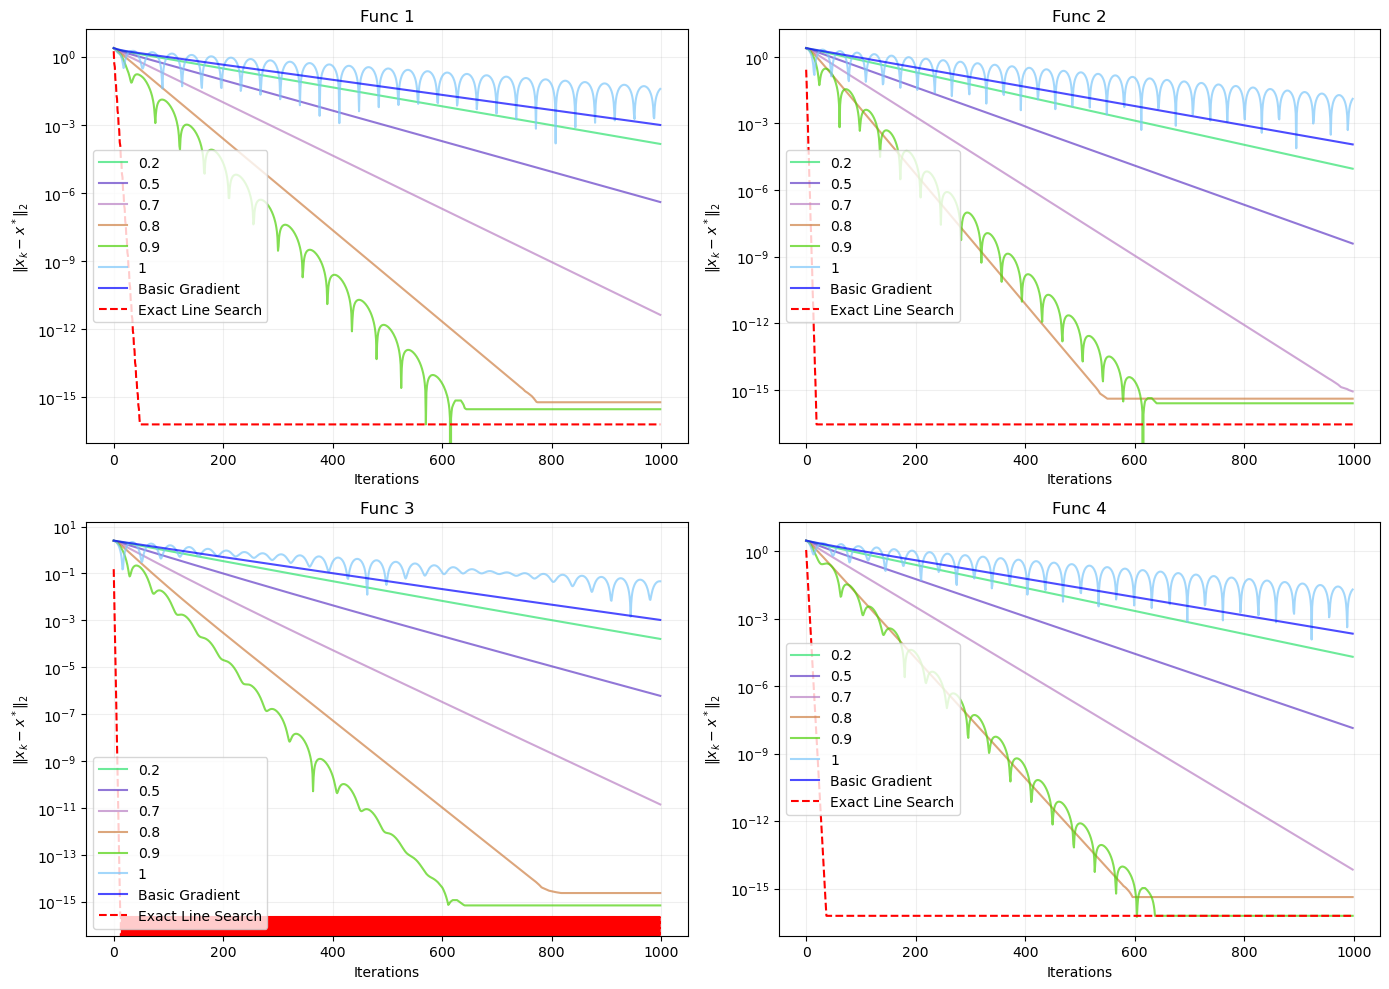

In [124]:
plt.figure(figsize=(14,10))
iterations = np.arange(1,1000)
for j in range(4):
    tmp = np.random.randn(2,2)
    A = tmp.T @ tmp +np.eye(2)
    b = np.random.randn(2)
    x_initial = np.array([2.0, -2.0])
    exact = np.linalg.solve(A,b)

    eigvals = np.linalg.eigvals(A)
    L = np.max(eigvals)
    mu = np.min(eigvals)
    lr = 1/L

    momentums = [0.2, 0.5, 0.7, 0.8, 0.9, 1]
    colors = ['#2FE26F','#633DC7','#BA81C4','#CE8045','#4ED009','#7DC7FA','#E1157F','#4D7953','#D831CC']
    plt.subplot(2,2,j+1)
    iters_range = range(len(iterations))
    _, errorVan = Basic_Gradient(A, b, x_initial, learningRate, iterations, exact)
    _, errorExactLine = gradient_with_ExactLine(A, b, x_initial, iterations, exact)
    d= 0
    for m in momentums:
        _, eM1 = nesterovs_gradient(A, b, x_initial, learningRate, iterations, exact, m)
        plt.semilogy(iters_range, eM1, label=m, color=colors[d], alpha=0.7)
        d+=1
    plt.semilogy(iters_range, errorVan, label='Basic Gradient', color='blue', alpha=0.7)
    plt.semilogy(iters_range, errorExactLine, label='Exact Line Search', color='red', linestyle='--')
    plt.title(f"Func {j+1}")
    plt.xlabel("Iterations")
    plt.ylabel('$\|x_k - x^*\|_2$')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

[[-0.02259642  0.05160453]]


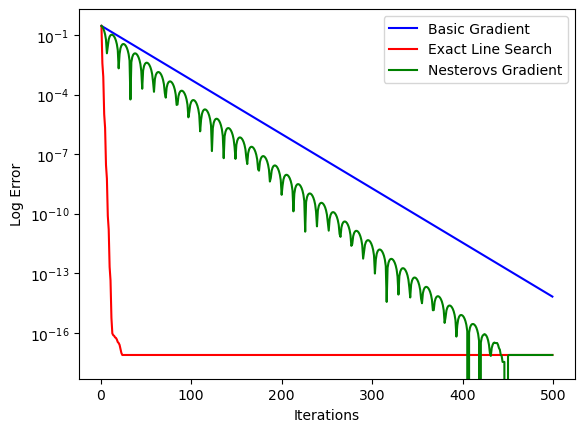

In [5]:
A = np.array([[118,63],[63,46]])
b=np.array([0.58470757, 0.95023374])
x_initial = np.ones(2)
tol = eps
L = np.max(np.linalg.eigvals(A))
learningRate = 1/L #Lipschitz constant 
iterations = np.arange(1,500)
exact = np.array([np.linalg.solve(A,b)])
print(exact)
xBG, errorsBG = Basic_Gradient(A, b, x_initial, learningRate, iterations,exact)
xGE, errorsGE = gradient_with_ExactLine(A, b, x_initial, iterations,exact)
xNG, errorsNG = nesterovs_gradient(A, b, x_initial, learningRate, iterations,exact, 0.9)
plt.semilogy(iterations, errorsBG, 'b-', iterations, errorsGE, 'r-', iterations, errorsNG, 'g-')
plt.xlabel('Iterations')
plt.ylabel('Log Error')
plt.legend(['Basic Gradient', 'Exact Line Search', 'Nesterovs Gradient'])

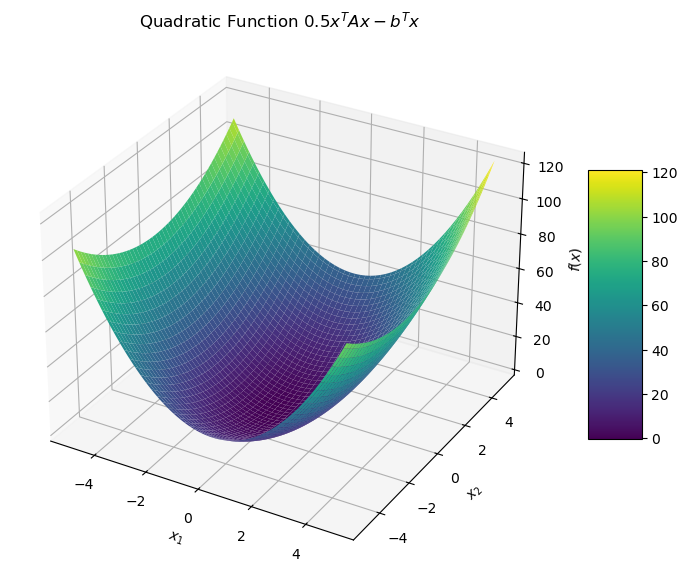

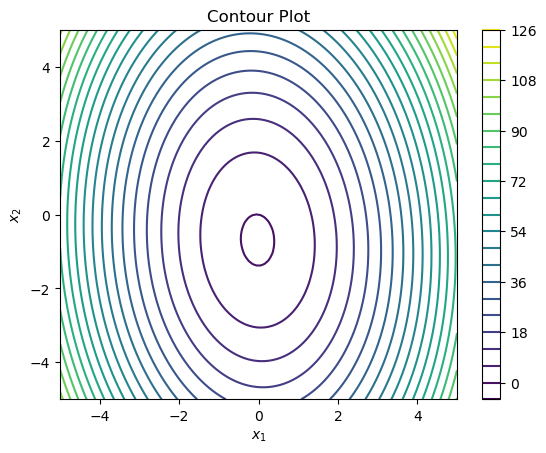

In [6]:
def fu(x1, x2, A, b):
    return 0.5 * (A[0,0]*x1**2 + (A[0,1]+A[1,0])*x1*x2 + A[1,1]*x2**2) - (b[0]*x1 + b[1]*x2)
tmp = np.random.randn(2,2)
A = tmp.T @ tmp +np.eye(2)
b = np.random.randn(2)
x1 = np.linspace(-5,5,100)
x2 = np.linspace(-5,5,100)
X1, X2 = np.meshgrid(x1, x2)
Z = fu(X1, X2, A, b)
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none')

ax.set_title('Quadratic Function $0.5x^TAx - b^Tx$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x)$')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

# 5. Optional: Contour Plot
plt.figure()
plt.contour(X1, X2, Z, levels=20)
plt.title('Contour Plot')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.colorbar()
plt.show()

###### Convergence Rate Differences 
$$\kappa = \frac{\lambda_{\text{max}}(A)}{\lambda_{\text{min}}(A)}$$
<b> Exact Line Search</b> $$(\frac{\kappa - 1}{\kappa + 1})^{\kappa}$$
Nesterov's Accelerated Gradient has a convergence rate of $\frac{1}{\kappa^2}$
$\beta = \frac{\sqrt{L/m}-1}{\sqrt{L/m}+1}$
$L$ is smoothness. $m$ is strong convexity. $\beta$ is the momentum 
<a href="https://pages.cs.wisc.edu/~yudongchen/cs726_sp23/Lecture_9_10_accelerated_GD.pdf">Source</a>

# Task 1B: Visualizing the Path of Gradient Descent

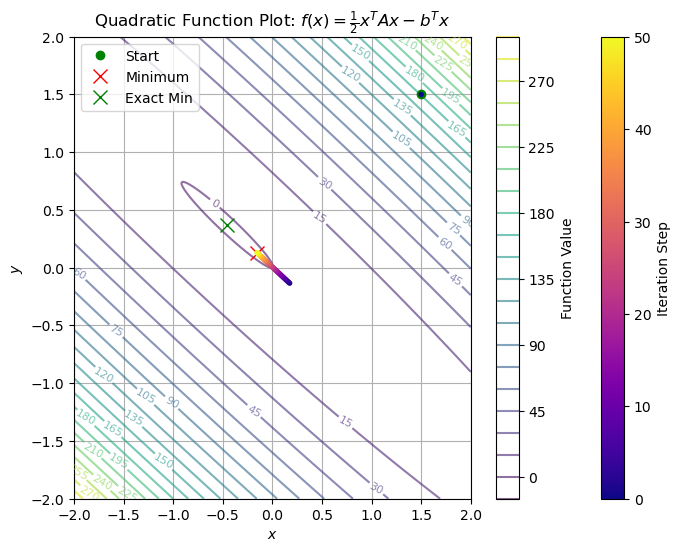

In [7]:
# Av= np.array([[51,18],[18,21]])
# bv = np.array([-1.98468569, 0.54850085])

Av = np.random.randint(1, 10, size=(2,2)) #low, high
Av = Av.T @ Av + np.eye(2)
bv = np.random.randn(2)
def f(x, y, A, b):
    return 0.5 * (A[0,0]*x**2 + (A[0,1] + A[1,0])*x*y + A[1,1]*y**2) - (b[0]*x + b[1]*y)
def visualizeGradientVanilla(A, b, start, learningRate, iterations):
    x = start.astype(float)
    xPoints = [x.copy()]
    errors = []
    for i in iterations:
        gradient = A @ x - b
        x = x - learningRate * gradient
        approxValue = np.array([f(x[0],x[1], A, b)])
        error_vector = np.abs(exact - approxValue)
        errors.append(np.linalg.norm(error_vector)) #l2 norm
        point = x
        xPoints.append(x.copy())
    return x, np.array(xPoints), errors

#plotting Function
xV = np.linspace(-2, 2, 400)
yV = np.linspace(-2,2,400)
X, Y = np.meshgrid(xV, yV)
Z = f(X, Y, Av, bv)
exact = np.linalg.solve(Av, bv)

plt.figure(figsize=(8,6))
contour = plt.contour(X, Y, Z,levels=20, cmap='viridis', alpha = 0.6)
plt.clabel(contour, inline = True, fontsize=8)
plt.title('Quadratic Function Plot: $f(x) = \\frac{1}{2} x^T Ax - b^T x$')
plt.xlabel('$x$')
plt.ylabel('$y$')

#finding path 
start = np.array([1.5, 1.5])
its = range(50)
L = np.max(np.linalg.eigvals(Av))
learningRate = 1/L 
final, path, errs = visualizeGradientVanilla(Av, bv, start, learningRate, its)
path = np.array(path)
#back to plotting
step_indices = np.arange(len(path))

scatter = plt.scatter(path[:,0], path[:,1], c=step_indices, cmap='plasma', s=15, edgecolors='none', zorder=3)
cbar = plt.colorbar(scatter)
cbar.set_label('Iteration Step')
plt.plot(path[0, 0], path[0,1], 'go', label='Start')
plt.plot(final[0], final[1], 'rx', markersize=10, label='Minimum')
plt.plot(exact[0], exact[1], 'gx', markersize=10, label='Exact Min')
plt.legend()
plt.colorbar(contour, label='Function Value')
plt.grid(True)
plt.show()

# Task #2 Minimizing a Non Convex Test Function

Rosenbrock's Banana Function is: 
$$f(x,y)= (a - x)^2 + b (y-x^2)^2$$
It has a global minimum at $(x, y) = (a, a^2)$, where $f(x, y) = 0$. The gradient of Rosenbrock's Banana is 
$$\frac{\partial f}{\partial x} = -2a + 4bx(x^2 - y)+2x$$
$$\frac{\partial f}{\partial y} = 2b (-x^2 +y)$$ 
Since,
$$\nabla f = (\frac{\partial f}{\partial x} \frac{\partial f}{\partial y})$$ 
$$\nabla f =  \left(-2a + 4bx(x^2 - y)+2x, 2b (-x^2 +y) \right)$$

In [95]:
tol = eps
a = 1
b = 100
def Rosenbrock(x, y, a = 1, b = 100):
    value = (a-x)**2 + b*(y-x**2)**2
    return value
def gradientRosenbrock(x,y, a = 1, b = 100):
    df_dx = -2*a + 4*b*x*(x**2 - y) + 2*x
    df_dy = 2 * b * (-x**2 + y)
    return np.array([df_dx, df_dy])
def function_basic_gradient(func, grad, exact, start, learningRate, iterations):
    x = np.array(start)
    errors = []
    history = []
    for i in iterations:
        gradient = grad(x[0],x[1])
        x = x - learningRate * gradient
        error = np.linalg.norm(x - exact)
        errors.append(error) #l2 norm
        history.append(x.copy())
    return x, errors, history
#since we cannot use minimize_vector
def exactLineSearch(func, x, direction, bounds=[0,0.05], pts=500):
    alphas = np.linspace(bounds[0], bounds[1], pts) 
    values = [func((x+alpha*direction)[0], (x+alpha*direction)[1]) for alpha in alphas]
    best = alphas[np.argmin(values)]
    return best
def run(meth,func, gradient, start, exact, iterations, lr=0.001):
    x = start.copy()
    history = [x.copy()]
    errors = []
    v = np.zeros_like(x) #velocities
    m = 0.9 #momentum
    for i in iterations:
        grad = gradient(x[0], x[1])
        if np.linalg.norm(grad)<tol:
            errors.extend([errors[-1]] * (len(iterations)-len(errors)))
            break
        if meth=='van':
            lr = 0.002
            x = x-lr*grad
        elif meth=='EL':
            alpha = exactLineSearch(func, x, -grad)
            x = x-alpha*grad
        elif meth=='nest':
            lookAhead = x+ m *v
            gradAhead = gradient(lookAhead[0], lookAhead[1]) 
            v = m * v - lr * gradAhead
            x = x+ v
        history.append(x.copy())
        errors.append(np.linalg.norm(x-exact))
    return history, errors, x
exact = np.array([a, a**2])
start = [0,0]

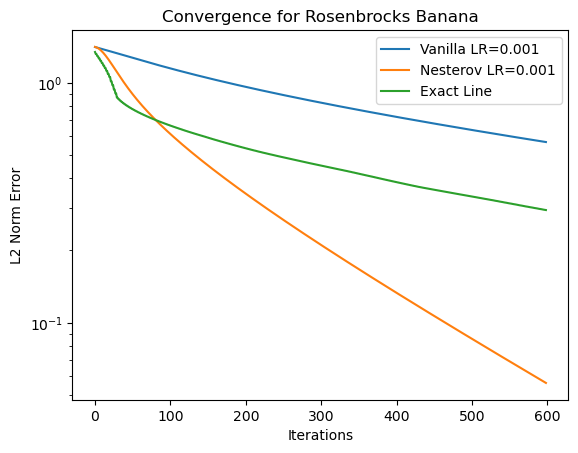

Vanilla Final Pos: [0.71517113 0.51013044], Error: 0.566657
Exact Final Pos:   [0.86074783 0.74005897], Error: 0.294891
Nesterov Final Pos:[0.9747189  0.94997421], Error: 0.056051


In [43]:

its = range(1,600)
l=0.001
histVan, errVan, xVan = run('van', Rosenbrock, gradientRosenbrock, start, exact, its, l)
histN, errN, xN = run('nest', Rosenbrock, gradientRosenbrock, start, exact, its, l)
histEL, errEL, xEL = run('EL', Rosenbrock,gradientRosenbrock, start, exact, its)
plt.plot(errVan, label=f'Vanilla LR={l}')
plt.plot(errN, label=f'Nesterov LR={l}')
plt.plot(errEL, label=f'Exact Line')
plt.yscale('log')
plt.legend()
plt.ylabel('L2 Norm Error')
plt.xlabel('Iterations')
plt.title('Convergence for Rosenbrocks Banana')

plt.show()
#range(len(errVan))
print(f"Vanilla Final Pos: {histVan[-1]}, Error: {errVan[-1]:.6f}")
print(f"Exact Final Pos:   {histEL[-1]}, Error: {errEL[-1]:.6f}")
print(f"Nesterov Final Pos:{histN[-1]}, Error: {errN[-1]:.6f}")

###### Plotting Learning Rates Impact on Convergence for Rosenbrock

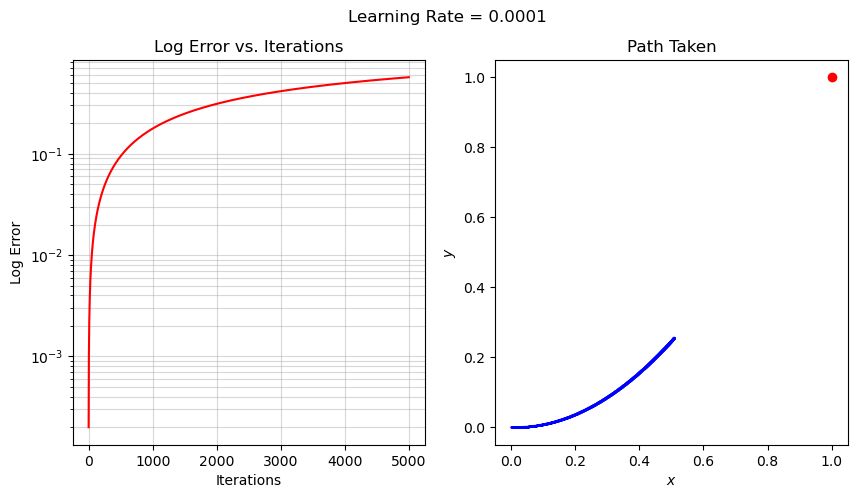

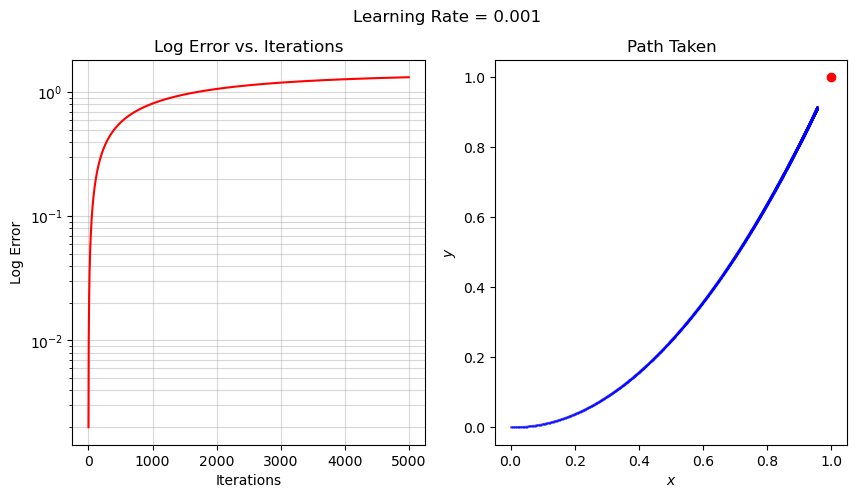

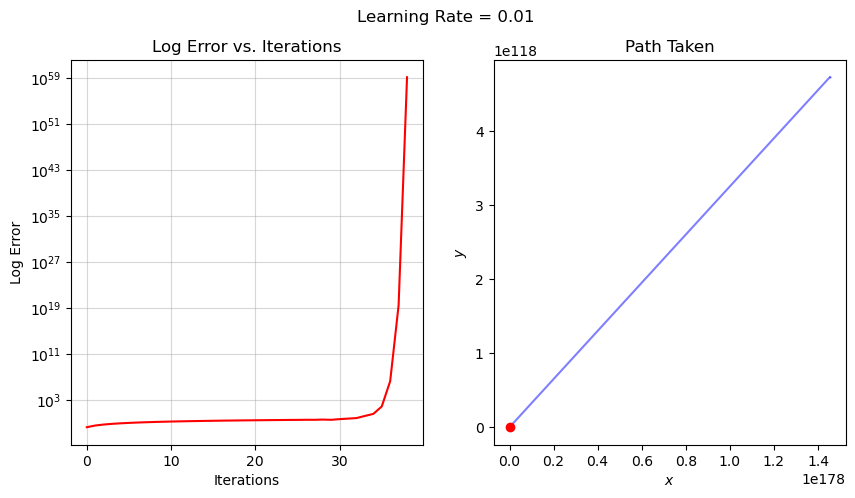

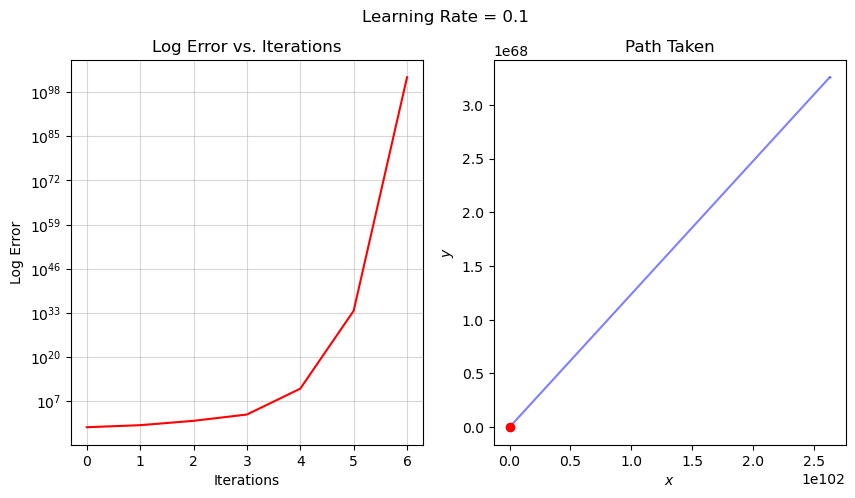

In [99]:
lrs = [0.0001, 0.001, 0.01, 0.1]
#plotting 
import warnings
warnings.filterwarnings('ignore')
for lr in lrs:
    iterations = range(1,5000)
    v, errors, path = function_basic_gradient(Rosenbrock, gradientRosenbrock, exact, [0,0], lr, iterations)
    plt.figure(figsize=(10,5))
    plt.suptitle(f"Learning Rate = {lr}")
    plt.subplot(1,2,1)
    plt.semilogy(range(len(errors)), errors, 'r-')
    plt.xlabel('Iterations')
    plt.ylabel('Log Error')
    plt.title('Log Error vs. Iterations')
    plt.grid(True, which="both", ls="-", alpha = 0.5)
    path = np.array(path)
    plt.subplot(1,2,2)
    plt.plot(path[:,0], path[:,1], 'b.-', markersize=1, alpha = 0.5)
    plt.plot(a, a**2, 'ro') #minimum
    plt.title('Path Taken')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.show();

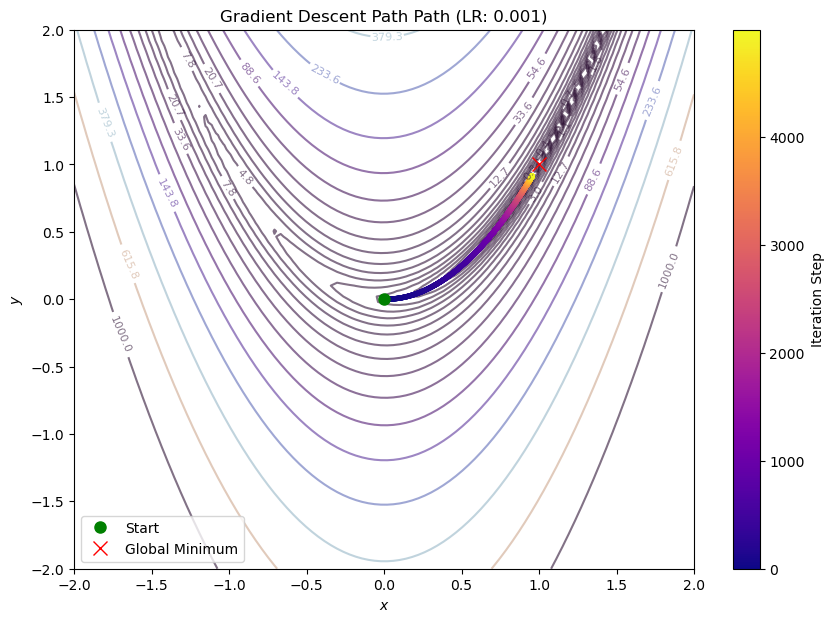

In [67]:
exact = np.array([a, a**2])
lr = 0.001

v, errors, path = function_basic_gradient(Rosenbrock, gradientRosenbrock, exact, [0,0], lr, iterations)
path = np.array(path)

#colorbar to show time
step_indices = np.arange(len(path))
plt.figure(figsize=(10,7))

#Contours Rosenbrock
levels = np.logspace(-1,3,20)
x = np.linspace(-2, 2, 100)
y = np.linspace(-2,2,100)
X, Y = np.meshgrid(x,y)
Z = Rosenbrock(X, Y)
contour = plt.contour(X, Y, Z, levels=levels, cmap='twilight_shifted', alpha=0.6)
plt.clabel(contour, inline = True, fontsize=8)
# plot the line 
plt.plot(path[:,0], path[:,1], color='black', lw=1, alpha=0.3, zorder=2)

scatter = plt.scatter(path[:,0], path[:,1], c=step_indices, cmap='plasma', s=15, edgecolors='none', zorder=3)
cbar = plt.colorbar(scatter)
cbar.set_label('Iteration Step')
plt.plot(path[0,0], path[0,1], 'go', markersize=8, label='Start', zorder=5)
plt.plot(exact[0], exact[1], 'rx', markersize=10, label='Global Minimum', zorder=5)
plt.title(f'Gradient Descent Path Path (LR: {lr})') 
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show();


### Graphing Rosenbrock

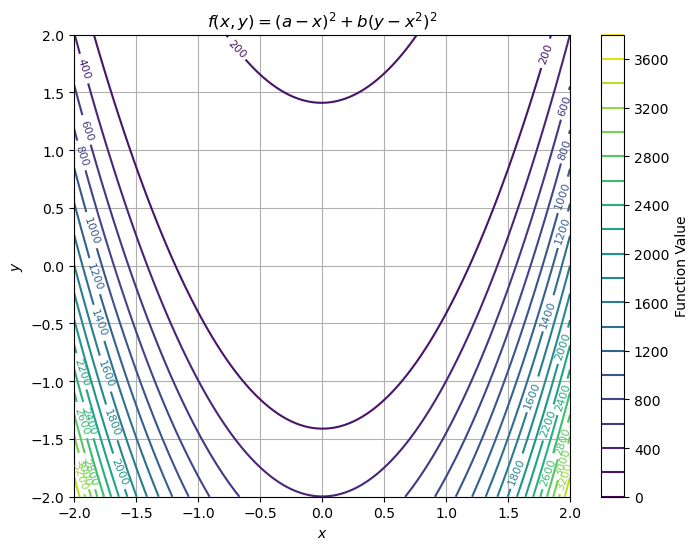

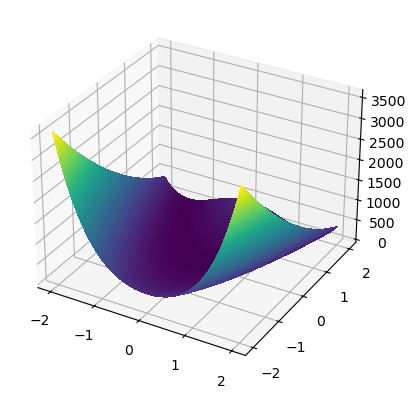

In [18]:
a, b = 1, 100
minimum = np.array([a, a**2])
xV = np.linspace(-2, 2, 200)
yV = np.linspace(-2,2,200)
X, Y = np.meshgrid(xV, yV)
Z = Rosenbrock(X, Y)
plt.figure(figsize=(8,6))
contour = plt.contour(X, Y, Z, 20, cmap='viridis')
plt.clabel(contour, inline = True, fontsize=8)
plt.title('$f(x,y) = (a - x)^2 + b (y - x^2)^2$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.colorbar(contour, label='Function Value')
plt.grid(True)
plt.show()
ax = plt.figure().add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis', linewidth=0, antialiased=False)    

# Task 2.b Rastrigin

In [77]:
def Rastrigin(x, y):
    A = 10
    #return A* len(X) + sum([(x**2 - A * np.cos(2* np.pi *x)) for x in X])
    return A * 2 + (x**2 - A *np.cos(2*np.pi *x)) + (y**2 - A*np.cos(2*np.pi *y))
def gradientRastrigin(x, y):
    df_one = 2*x + 2*np.pi * 10 * np.sin(2*np.pi * x)
    df_two = 2*y + 2*np.pi *10 *np.sin(2*np.pi * y)
    return np.array([df_one, df_two])

C:\Users\sandidgef2858\AppData\Local\Temp\ipykernel_6168\1410952271.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_error.legend()


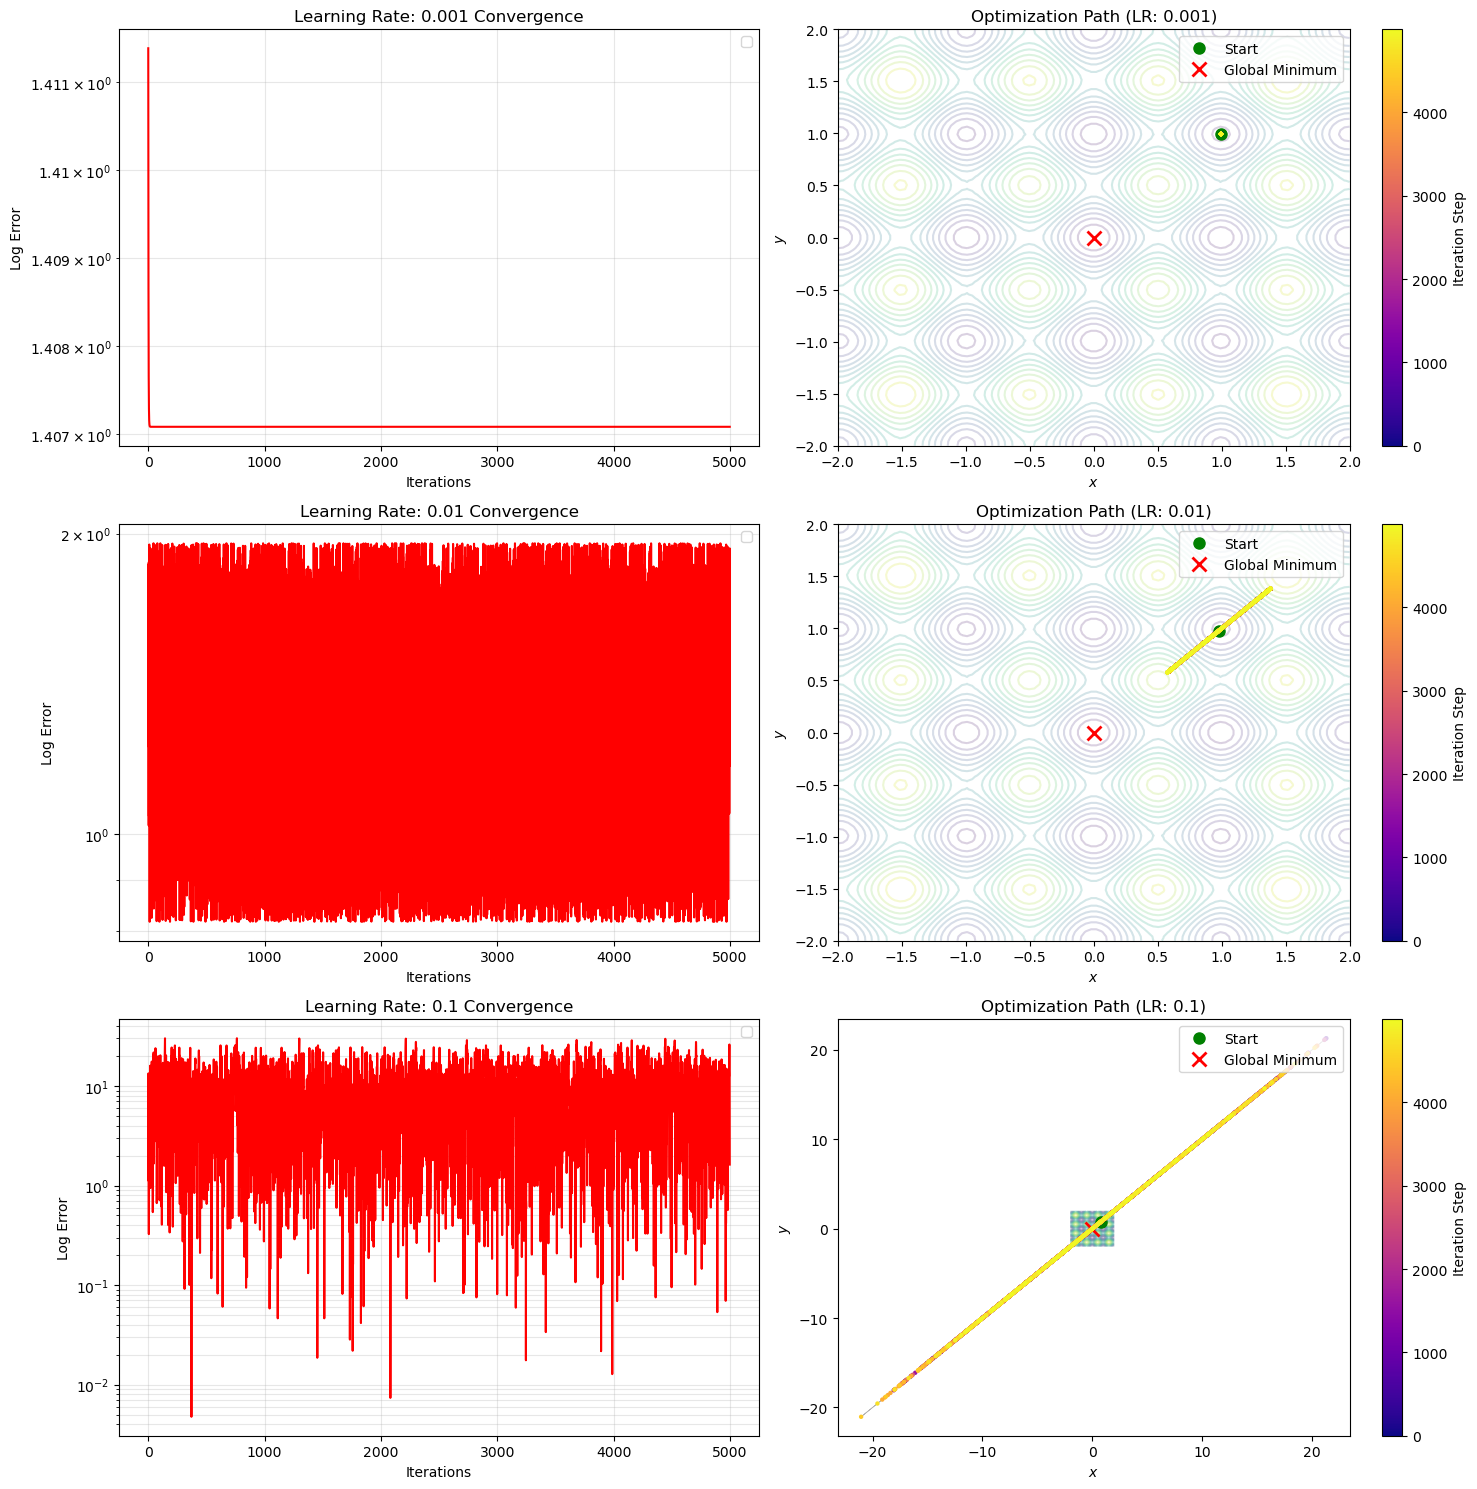

In [54]:
"""
Graphing Log Error Vs Iterations for Different Learning Rates and The Path of the Gradient Descent 
"""
iterations = range(1,5000)
exact = np.array([0,0])
lrs = [0.001, 0.01, 0.1]
fig, axs = plt.subplots(len(lrs), 2, figsize=(15, 5*len(lrs)))
for i, lr in enumerate(lrs):
    
    v, errors, path = function_basic_gradient(Rastrigin, gradientRastrigin, exact, [1,1], lr, iterations)
    ax_error = axs[i,0]
    ax_path = axs[i,1]
    # ERROR 
    ax_error.semilogy(range(len(errors)), errors, 'r-')
    ax_error.set_xlabel('Iterations')
    ax_error.set_ylabel('Log Error')
    ax_error.set_title(f'Learning Rate: {lr} Convergence')
    ax_error.grid(True, which="both", ls="-", alpha = 0.3)
    ax_error.legend()

    # PATH PLOT
    path = np.array(path)
    x_range = np.linspace(-2,2,100)
    y_range = np.linspace(-2,2,100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = Rastrigin(X,Y)
    ax_path.contour(X, Y, Z, levels = 15, cmap='viridis', alpha=0.2)
    
    #trajectory line
    ax_path.plot(path[:,0], path[:,1], 'k-', linewidth=0.5, alpha = 0.3) 
    step_indices = np.arange(len(path))
    scatter = ax_path.scatter(path[:,0], path[:,1], c=step_indices, cmap='plasma', s=10, edgecolors='none', zorder=3)
    
    cbar = fig.colorbar(scatter, ax = ax_path)    
    cbar.set_label('Iteration Step')
    ax_path.plot(path[0,0], path[0,1],'go', label='Start', markersize=8)
    ax_path.plot(exact[0],exact[1],'rx', markersize=10, label='Global Minimum', markeredgewidth=2)
    ax_path.set_title(f'Optimization Path (LR: {lr})')
    ax_path.set_xlabel('$x$')
    ax_path.set_ylabel('$y$')
    ax_path.legend(loc='upper right')
plt.tight_layout()
plt.show();

### Plotting Convergence for All 3 Gradient Descents 

Text(0.5, 1.0, 'Gradient Descent on Rastrigin Convergence Rate')

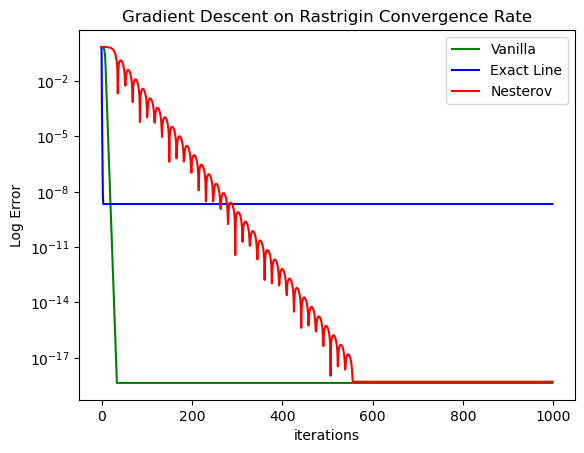

In [74]:
lr = 0.0001
iterations = np.arange(1, 1000)
start = [0.5,0.5]
exact = [0,0]
histV, errV, xv = run('van',Rastrigin, gradientRastrigin, start, exact, iterations, lr)
histEl, errEl, xE = run('EL',Rastrigin, gradientRastrigin, start, exact, iterations, lr)
histNest, errN, xN = run('nest', Rastrigin, gradientRastrigin, start, exact, iterations, lr)
plt.semilogy(np.arange(len(errV)), errV, 'g-', np.arange(len(errEl)), errEl, 'b-', np.arange(len(errN)), errN, 'r-')
plt.legend(['Vanilla', 'Exact Line', 'Nesterov'])
plt.xlabel('iterations')
plt.ylabel('Log Error')
plt.title('Gradient Descent on Rastrigin Convergence Rate')

##### Paths of All 3

In [102]:
def runA(meth,func, gradient, start, exact, iterations, lr=0.001):
    x = start.copy()
    history = [x.copy()]
    errors = []
    v = np.zeros_like(x) #velocities
    m = 0.9 #momentum
    for i in iterations:
        grad = gradient(x[0], x[1])
        if np.linalg.norm(grad)<tol:
            errors.extend([errors[-1]] * (len(iterations)-len(errors)))
            break
        if meth=='van':
            lr = 0.002
            x = x-lr*grad
        elif meth=='EL':
            alpha = exactLineSearch(func, x, -grad)
            x = x-alpha*grad
        elif meth=='nest':
            lookAhead = x+ m *v
            gradAhead = gradient(lookAhead[0], lookAhead[1]) 
            v = m * v - lr * gradAhead
            x = x+ v
        history.append(x.copy())
        errors.append(np.linalg.norm(x-exact))
    return history, errors, x

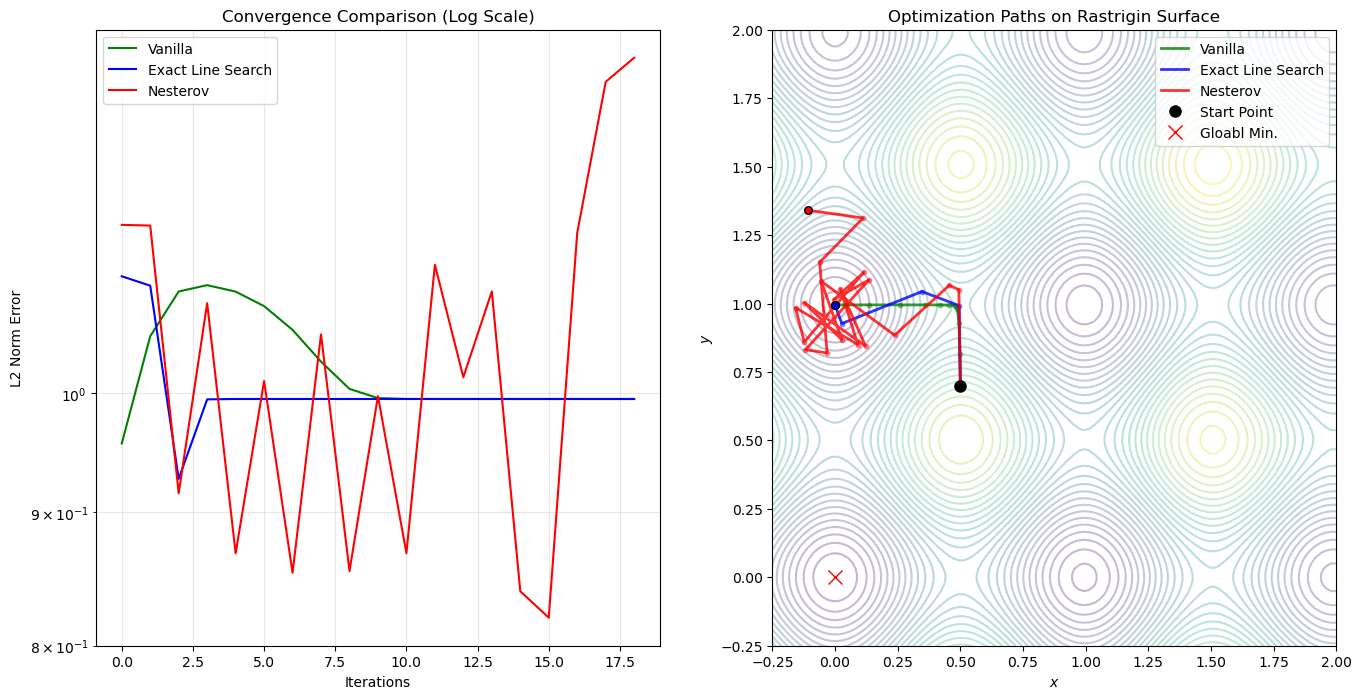

In [121]:
fig, (ax_error,ax_path) = plt.subplots(1,2, figsize=(16,8))
x_range = np.linspace(-2,2,200)
y_range = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x_range, y_range)
Z_mesh = Rastrigin(X, Y)
ax_path.contour(X, Y, Z_mesh, levels=30, cmap='viridis', alpha=0.3)
its = range(1,20)
exact = [0,0]
start = [0.5, 0.7] #if they'r the same number than they make a straight line and thats borring 
lr = 0.006
methods = [
    ('van', 'Vanilla', 'g'),
    ('EL', 'Exact Line Search', 'b'),
    ('nest', 'Nesterov', 'r')
]
minimumX = 0
for m, mName, mC in methods:
    path, errors, final = runA(m,Rastrigin, gradientRastrigin, start, exact, its, lr)
    path = np.array(path)
    errors = np.array(errors)
    ax_error.semilogy(errors, color=mC, label = mName)
    ax_path.plot(path[:, 0], path[:, 1], color=mC, label=mName, linewidth=2, alpha=0.8)
    ax_path.scatter(path[:, 0], path[:, 1], color=mC, s=10, alpha=0.4)    #dots 
    ax_path.scatter(path[-1, 0], path[-1, 1], color=mC, s=30, edgecolors='k', zorder=5) # Final point
ax_error.set_title('Convergence Comparison (Log Scale)')
ax_error.set_xlabel('Iterations')
ax_error.set_ylabel('L2 Norm Error')
ax_error.grid(True, which="both", ls="-", alpha=0.3)
ax_error.legend()
ax_path.set_xlim([-0.25, 2])
ax_path.set_ylim([-0.25,2])
ax_path.plot(start[0], start[1], 'ko', label='Start Point', markersize=8)
ax_path.plot(exact[0], exact[1], 'rx', label='Gloabl Min.', markersize=10,markeredgewidth=1)
ax_path.set_title('Optimization Paths on Rastrigin Surface')
ax_path.set_xlabel('$x$')
ax_path.set_ylabel('$y$')
ax_path.legend()


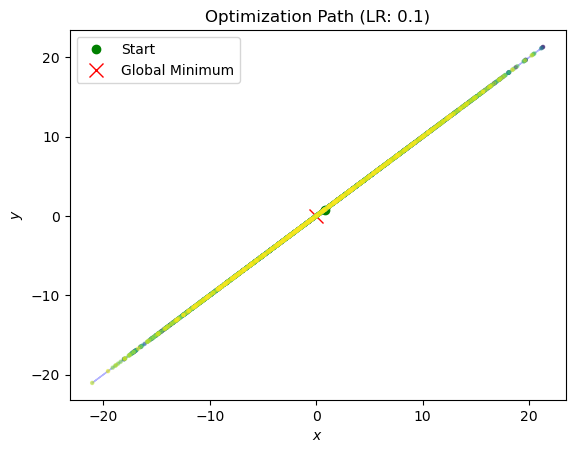

In [73]:
plt.plot(path[:,0], path[:,1], 'b-', linewidth=1, alpha = 0.3) 
step_indices = np.arange(len(path))
scatter = plt.scatter(path[:,0], path[:,1], c=step_indices, cmap='viridis', s=5, zorder=3, alpha=0.5)
plt.plot(path[0,0], path[0,1],'go', label='Start')
plt.plot(exact[0],exact[1],'rx', markersize=10, label='Global Minimum')
plt.title(f'Optimization Path (LR: {lr})')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()

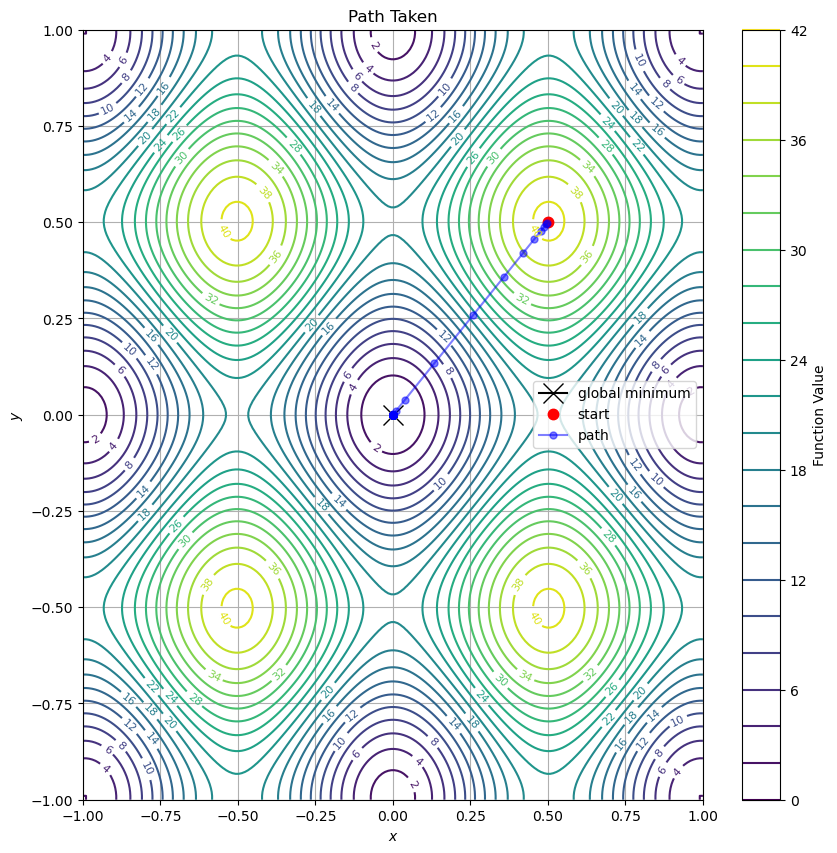

In [91]:
X = np.linspace(-1, 1, 200)
Y = np.linspace(-1,1,200)
X, Y = np.meshgrid(X, Y)
Z = Rastrigin(X, Y)
plt.figure(figsize=(10,10))
exact = [0,0]
contour = plt.contour(X, Y, Z, 20, cmap='viridis')
plt.clabel(contour, inline = True, fontsize=8)
plt.plot(0,0, marker='x', markersize= 15, color='black',label='global minimum')
plt.title('Rastrigin')
# Gradient 
#(func, grad, exact, start, learningRate, iterations
start = [0.5,0.5]
iterations = np.arange(1,500)
lr = 0.002
final, errors, path = function_basic_gradient(Rastrigin, gradientRastrigin, exact, start, lr, iterations) 
path = np.array(path)
# for x in path:
#     plt.scatter(x[0], x[1])
plt.plot(start[0], start[1], 'r.', markersize=15, label='start')
plt.plot(path[:,0], path[:,1], 'b.-', markersize=10, alpha = 0.5, label='path')
plt.title('Path Taken')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.colorbar(contour, label='Function Value')
plt.grid(True)

Text(0.5, 1.0, 'Log Error vs. Iterations')

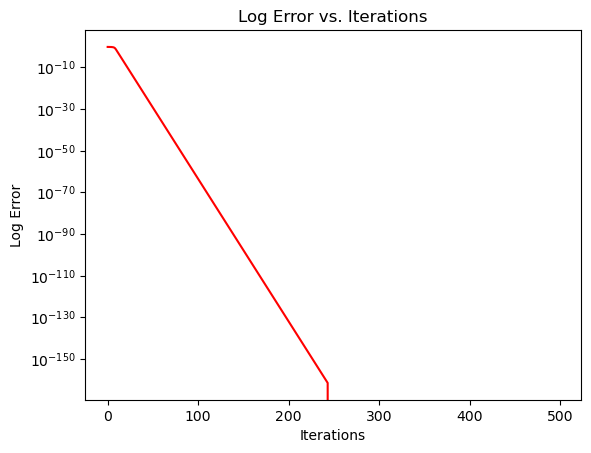

In [92]:
plt.semilogy(range(len(errors)), errors, 'r-')
plt.xlabel('Iterations')
plt.ylabel('Log Error')
plt.title('Log Error vs. Iterations')

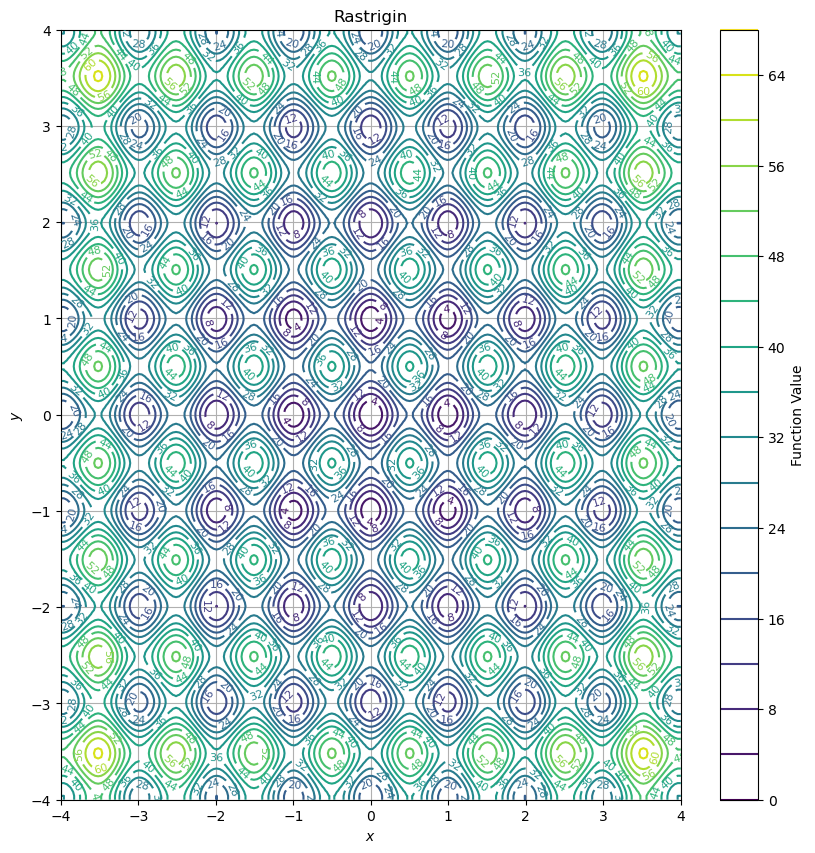

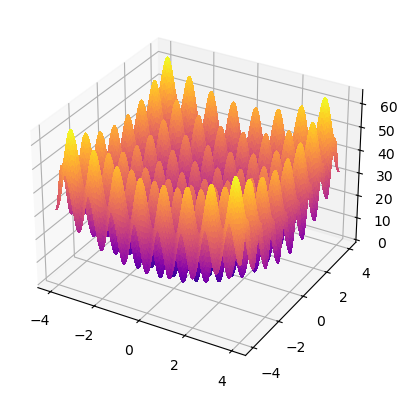

In [93]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
X = np.linspace(-4,4,200)
Y = np.linspace(-4,4,200)
X, Y = np.meshgrid(X, Y)
Z = Rastrigin(X, Y)
plt.figure(figsize=(10,10))

contour = plt.contour(X, Y, Z, 20, cmap='viridis')
plt.clabel(contour, inline = True, fontsize=8)
plt.title('Rastrigin')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.colorbar(contour, label='Function Value')
plt.grid(True)
#fig = plt.figure()
ax = plt.figure().add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.plasma, linewidth=0, antialiased=False)    